In [1]:
# # Credit Card Fraud Detection — Exploratory Data Analysis

# ## Objective

# This notebook performs Exploratory Data Analysis (EDA) on the credit card transaction dataset.

# The main objectives are to:

# - Understand the structure of the dataset
# - Examine the quality and completeness of the data
# - Analyse genuine and fraudulent transactions
# - Identify patterns and distributions in the features
# - Investigate possible outliers and anomalies
# - Understand class imbalance
# - Identify the preprocessing requirements for machine learning

# > Note: No data cleaning or preprocessing is performed in this notebook. 
# > The purpose of EDA is to understand the raw dataset and identify what preprocessing may be required.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("../Data/raw/creditcard.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 284807
Number of columns: 31


In [6]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [9]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

Total missing values: 0


In [10]:
missing_values[missing_values > 0]

Series([], dtype: int64)

In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0]

Series([], dtype: float64)

In [12]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1081


In [13]:
duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Duplicate percentage: {duplicate_percentage:.4f}%")

Duplicate percentage: 0.3796%


In [14]:
duplicates = df[df.duplicated(keep=False)]

duplicates.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,-0.484688,0.872490,0.851636,-0.571745,0.100974,-1.519772,-0.284376,-0.310524,-0.404248,-0.823374,-0.290348,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,-0.484688,0.872490,0.851636,-0.571745,0.100974,-1.519772,-0.284376,-0.310524,-0.404248,-0.823374,-0.290348,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,-0.482474,0.871800,0.853447,-0.571822,0.102252,-1.519991,-0.285912,-0.309633,-0.403902,-0.823743,-0.283264,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,-0.482474,0.871800,0.853447,-0.571822,0.102252,-1.519991,-0.285912,-0.309633,-0.403902,-0.823743,-0.283264,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,-0.243289,0.578063,0.674730,-0.534231,0.446601,1.122885,-1.768001,1.241157,-2.449500,-1.747255,-0.335520,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,-0.243289,0.578063,0.674730,-0.534231,0.446601,1.122885,-1.768001,1.241157,-2.449500,-1.747255,-0.335520,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,-0.243289,0.578063,0.674730,-0.534231,0.446601,1.122885,-1.768001,1.241157,-2.449500,-1.747255,-0.335520,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,-0.243289,0.578063,0.674730,-0.534231,0.446601,1.122885,-1.768001,1.241157,-2.449500,-1.747255,-0.335520,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,0.158497,-1.224951,1.314705,0.304412,-0.290218,-2.014548,-0.772801,0.696761,0.017914,2.177250,-0.276207,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,0.158497,-1.224951,1.314705,0.304412,-0.290218,-2.014548,-0.772801,0.696761,0.017914,2.177250,-0.276207,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0


In [15]:
duplicates["Class"].value_counts()

Class
0    1822
1      32
Name: count, dtype: int64

In [16]:
numeric_df = df.select_dtypes(include=np.number)

infinite_values = np.isinf(numeric_df).sum()

print("Total infinite values:", infinite_values.sum())

Total infinite values: 0


In [17]:
infinite_values[infinite_values > 0]

Series([], dtype: int64)

In [18]:
print("Unique values in Class:")
print(df["Class"].unique())

Unique values in Class:
[0 1]


In [20]:
print("Class value counts:")
print(df["Class"].value_counts())

Class value counts:
Class
0    284315
1       492
Name: count, dtype: int64


In [21]:
class_counts = df["Class"].value_counts()

print("Genuine transactions (0):", class_counts[0])
print("Fraudulent transactions (1):", class_counts[1])

Genuine transactions (0): 284315
Fraudulent transactions (1): 492


In [22]:
class_percentages = df["Class"].value_counts(normalize=True) * 100

print("Genuine (%):", class_percentages[0])
print("Fraudulent (%):", class_percentages[1])

Genuine (%): 99.82725143693798
Fraudulent (%): 0.1727485630620034


In [23]:
class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

class_summary.index = ["Genuine (0)", "Fraud (1)"]

class_summary

,Count,Percentage
Genuine (0),284315,99.827251
Fraud (1),492,0.172749


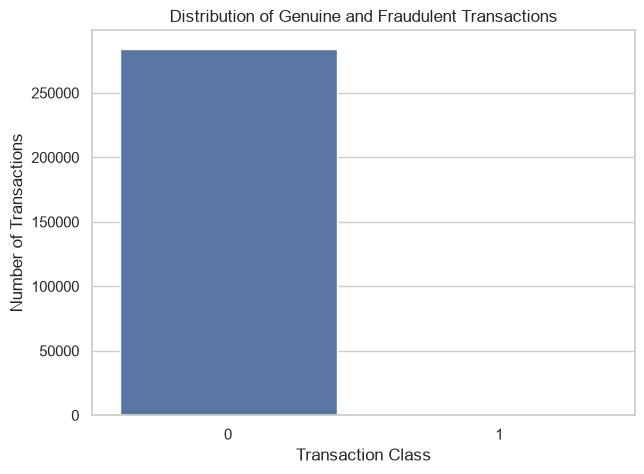

In [24]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Genuine and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

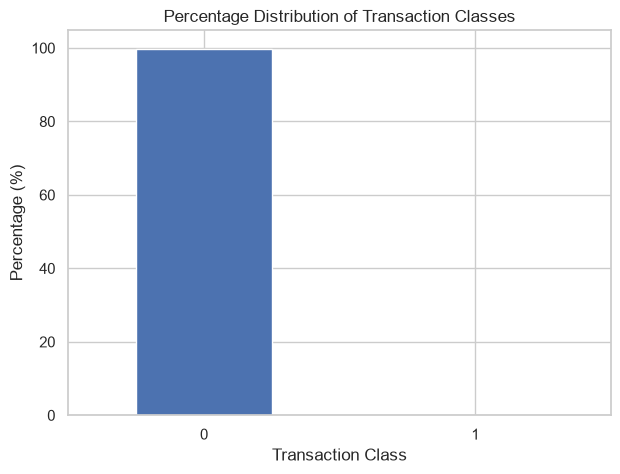

In [25]:
plt.figure(figsize=(7, 5))

class_percentages.plot(kind="bar")

plt.title("Percentage Distribution of Transaction Classes")
plt.xlabel("Transaction Class")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.show()

In [26]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [27]:
zero_amount = (df["Amount"] == 0).sum()

print("Transactions with Amount = 0:", zero_amount)

Transactions with Amount = 0: 1825


In [28]:
negative_amount = (df["Amount"] < 0).sum()

print("Transactions with negative Amount:", negative_amount)

Transactions with negative Amount: 0


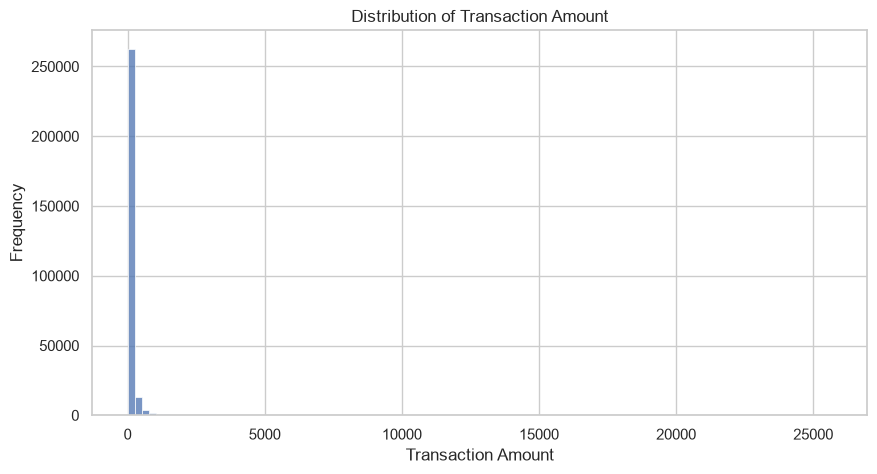

In [29]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Amount"], bins=100)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

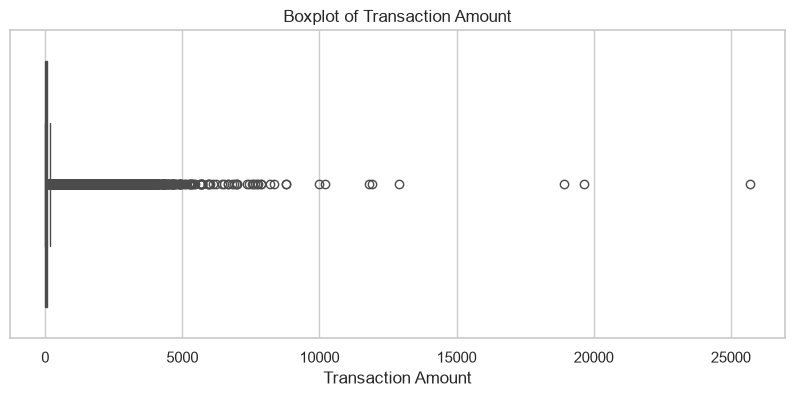

In [30]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df["Amount"])

plt.title("Boxplot of Transaction Amount")
plt.xlabel("Transaction Amount")

plt.show()

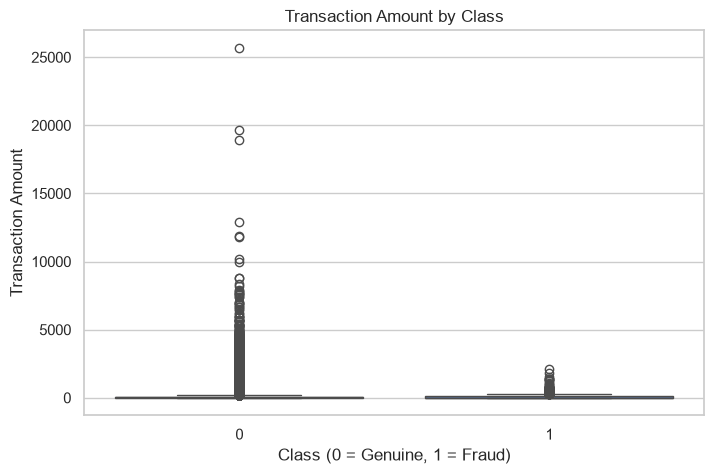

In [31]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Class", y="Amount")

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

In [32]:
df.groupby("Class")["Amount"].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"
])

,count,mean,median,std,min,max
Class,,,,,,
0,284315,88.291022,22.00,250.105092,0.0,25691.16
1,492,122.211321,9.25,256.683288,0.0,2125.87


In [33]:
df["Time"].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

In [34]:
print("Number of unique Time values:", df["Time"].nunique())

Number of unique Time values: 124592


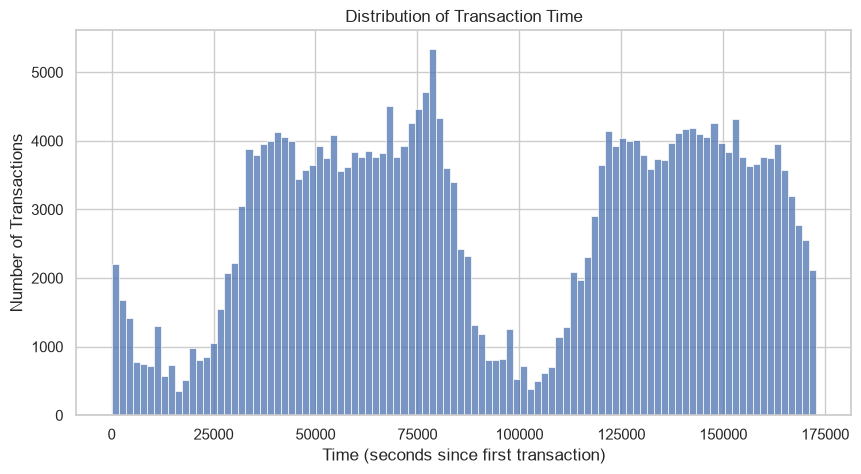

In [35]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Time"], bins=100)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time (seconds since first transaction)")
plt.ylabel("Number of Transactions")

plt.show()

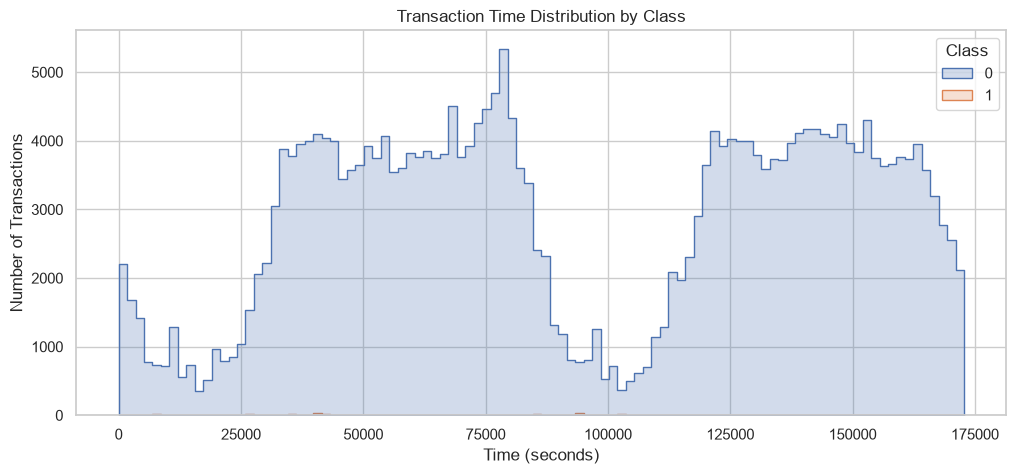

In [36]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=100,
    element="step"
)

plt.title("Transaction Time Distribution by Class")
plt.xlabel("Time (seconds)")
plt.ylabel("Number of Transactions")

plt.show()

In [37]:
df.groupby("Class")["Time"].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"
])

,count,mean,median,std,min,max
Class,,,,,,
0,284315,94838.202258,84711.0,47484.015786,0.0,172792.0
1,492,80746.806911,75568.5,47835.365138,406.0,170348.0


In [38]:
v_features = [f"V{i}" for i in range(1, 29)]

print("Number of V features:", len(v_features))
print(v_features)

Number of V features: 28
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']


In [39]:
df[v_features].describe().T

,count,mean,std,min,25%,50%,75%,max
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995
V10,284807.0,2.239053e-15,1.088850,-24.588262,-0.535426,-0.092917,0.453923,23.745136


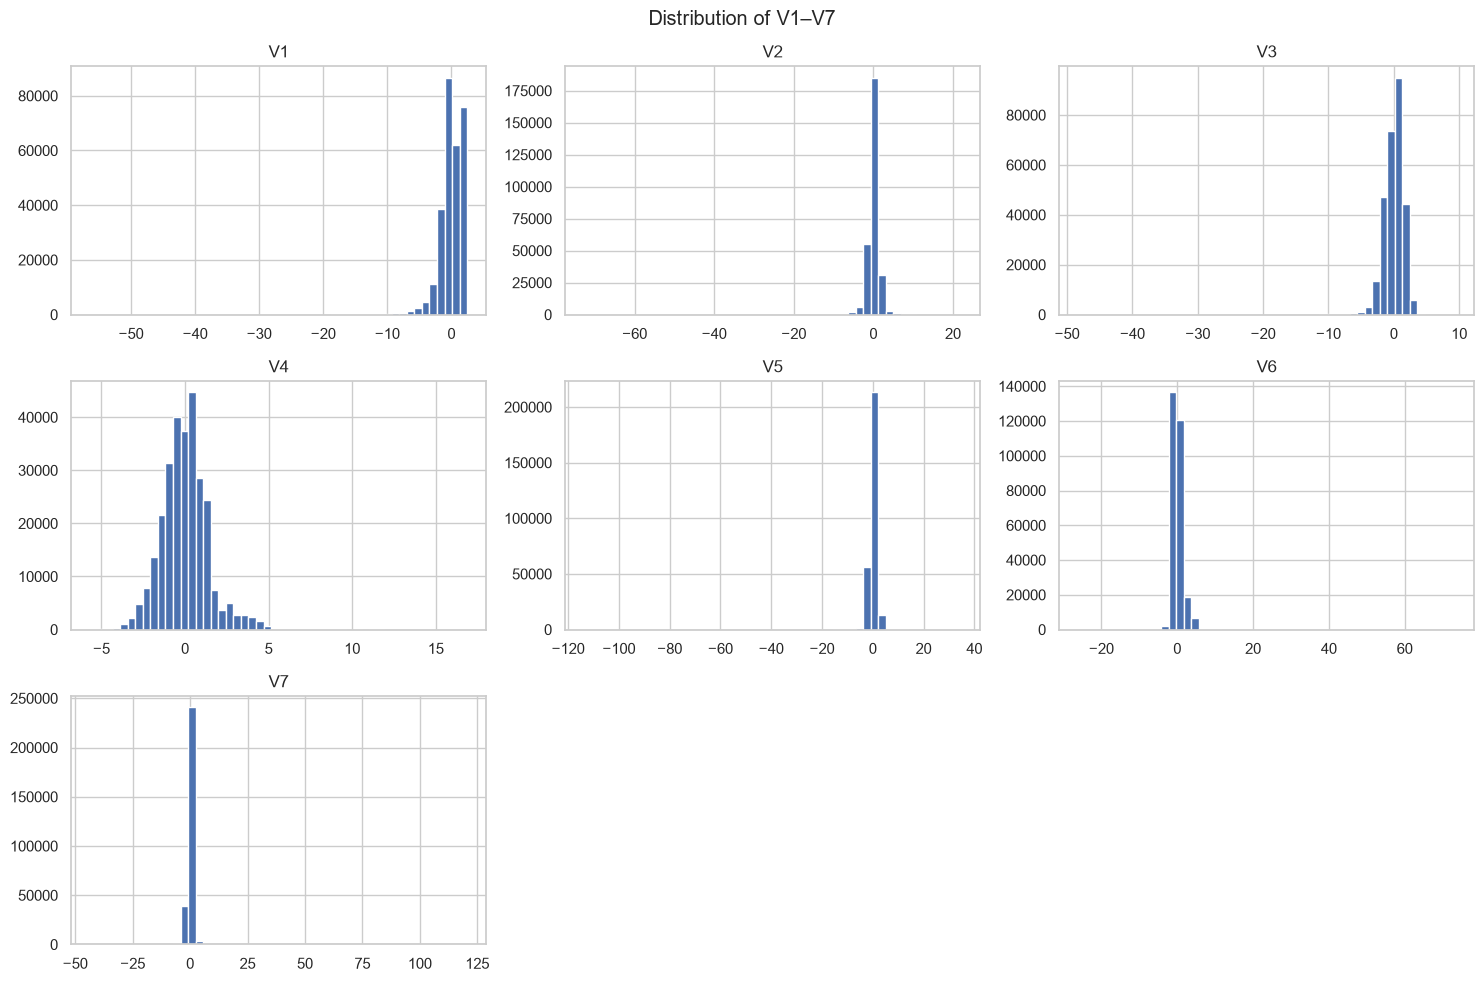

In [40]:
df[v_features[:7]].hist(
    bins=50,
    figsize=(15, 10)
)

plt.suptitle("Distribution of V1–V7")
plt.tight_layout()
plt.show()

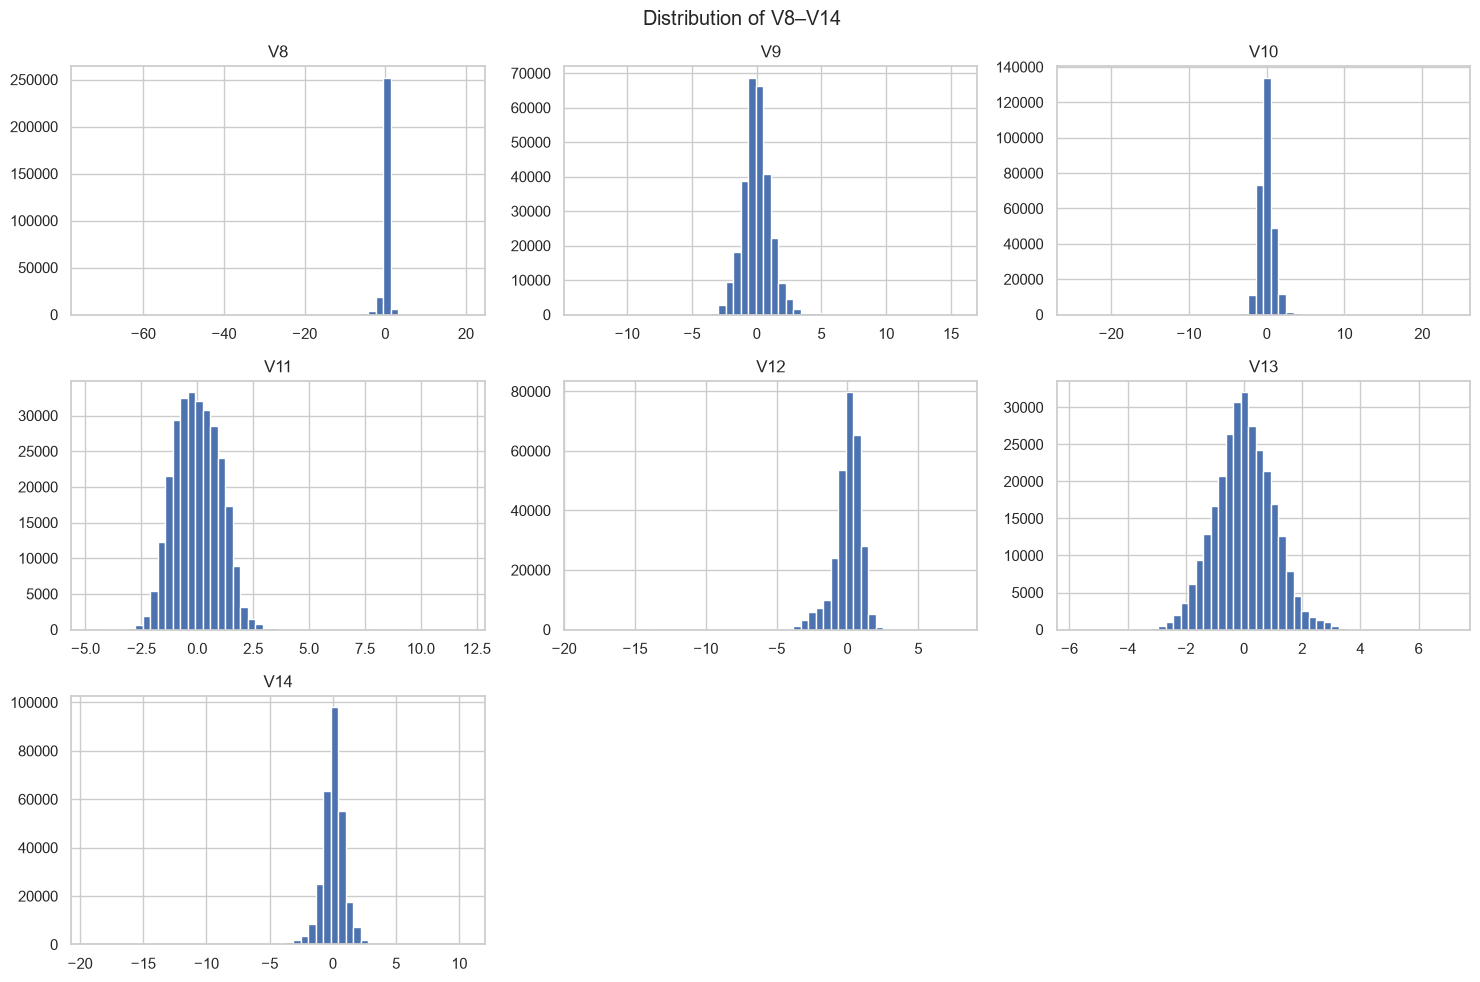

In [41]:
df[v_features[7:14]].hist(
    bins=50,
    figsize=(15, 10)
)

plt.suptitle("Distribution of V8–V14")
plt.tight_layout()
plt.show()

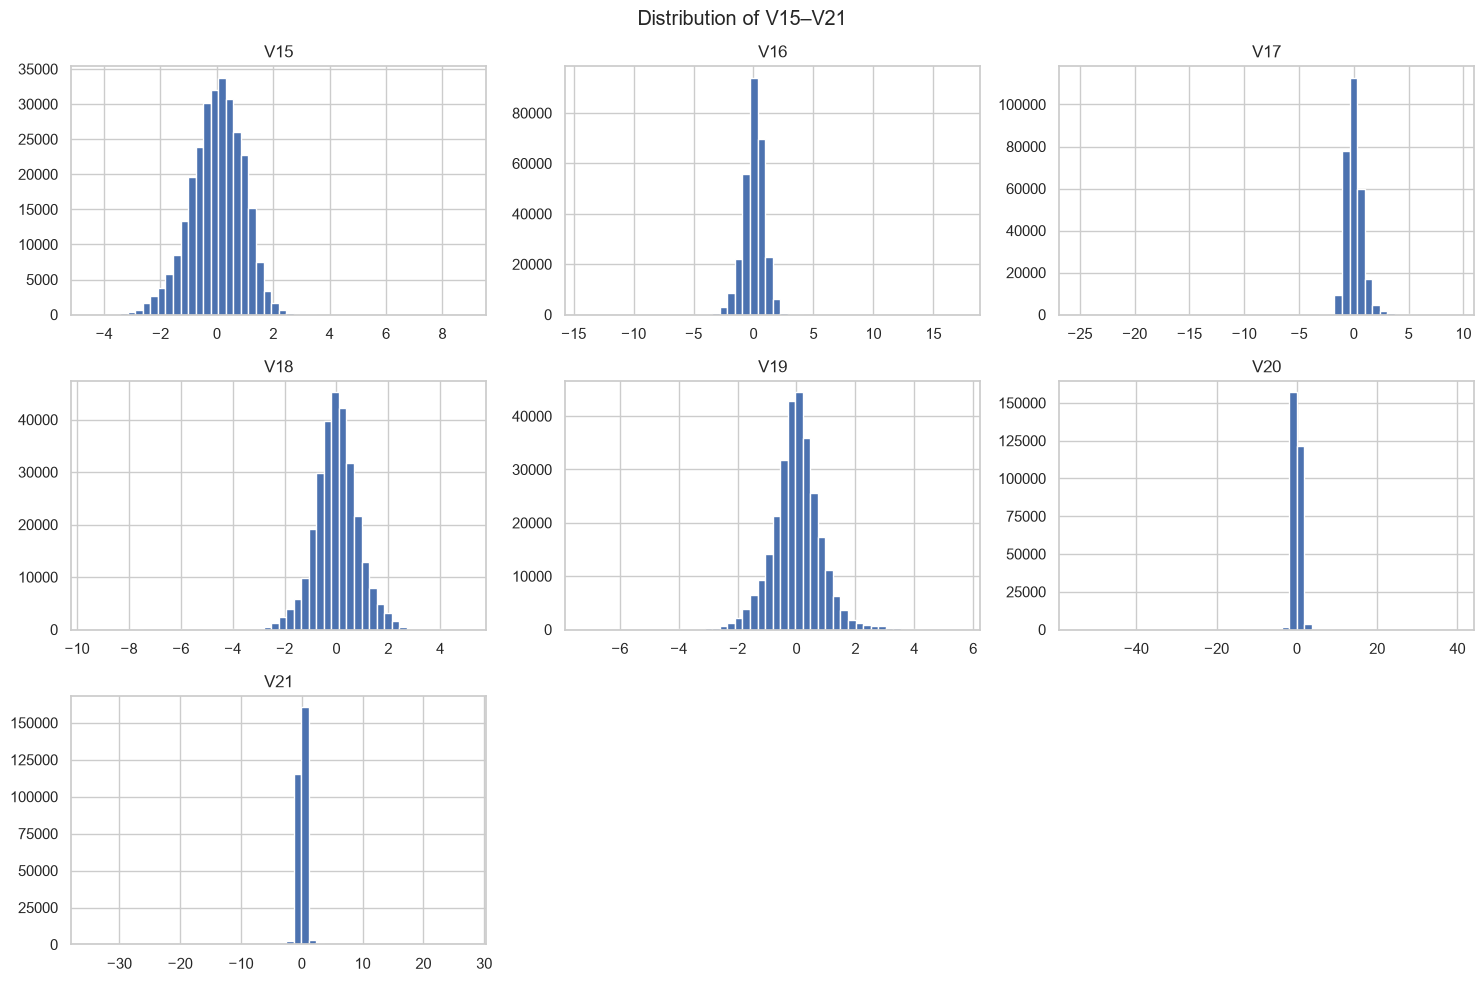

In [42]:
df[v_features[14:21]].hist(
    bins=50,
    figsize=(15, 10)
)

plt.suptitle("Distribution of V15–V21")
plt.tight_layout()
plt.show()

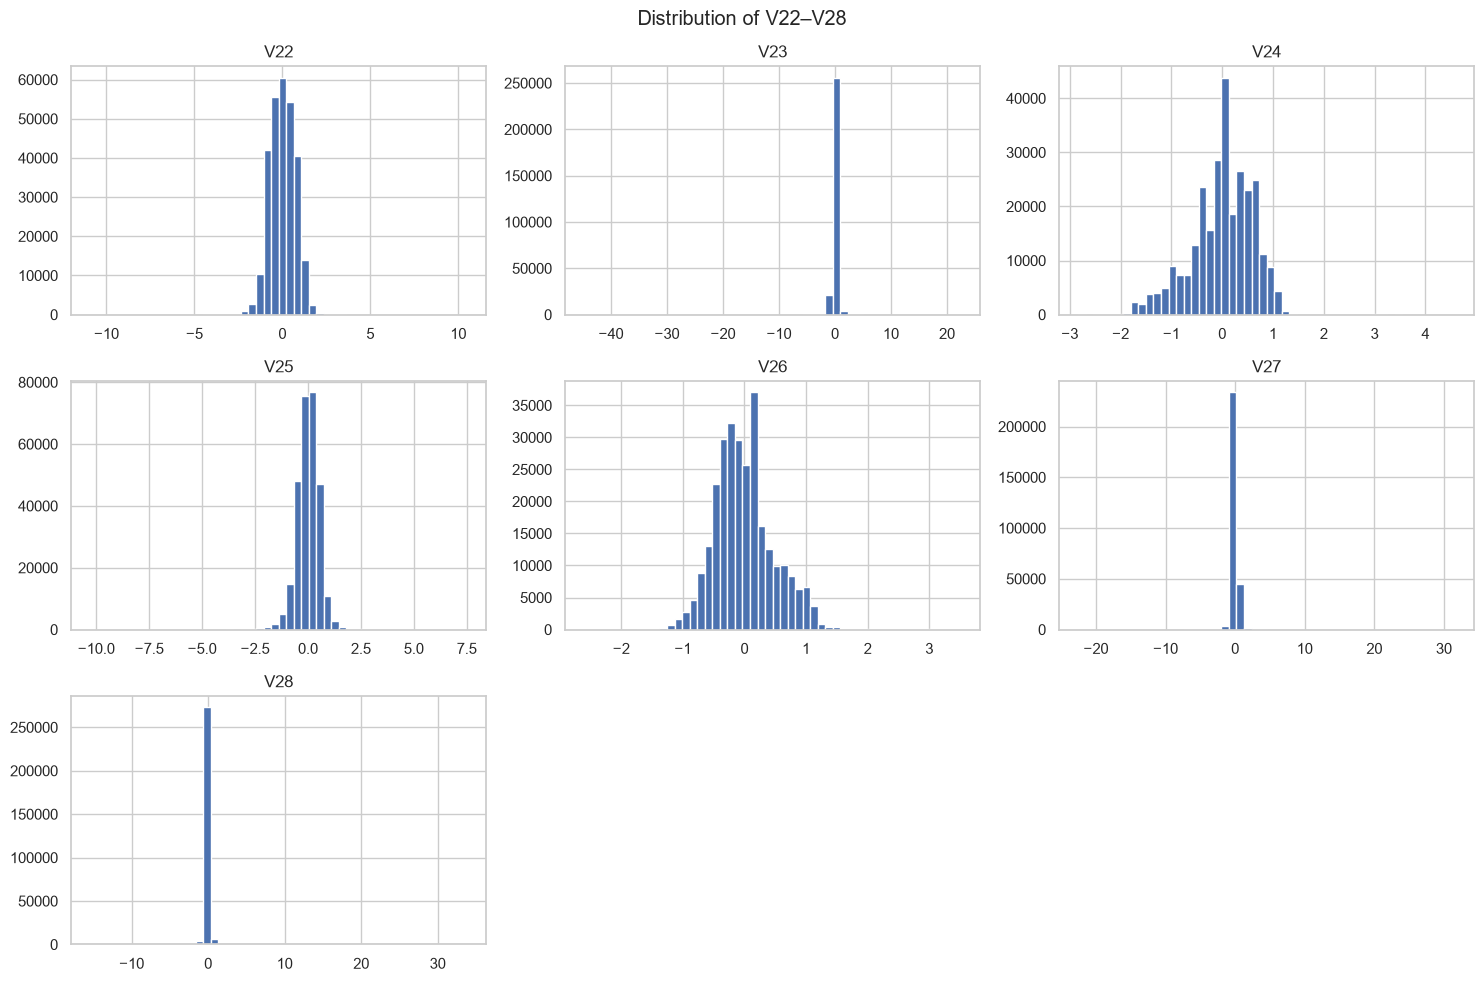

In [43]:
df[v_features[21:28]].hist(
    bins=50,
    figsize=(15, 10)
)

plt.suptitle("Distribution of V22–V28")
plt.tight_layout()
plt.show()

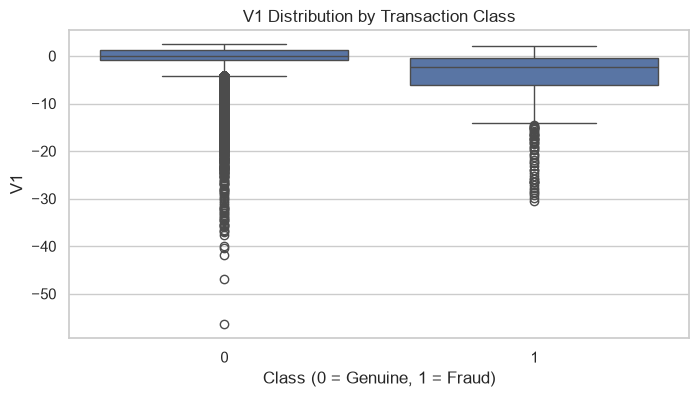

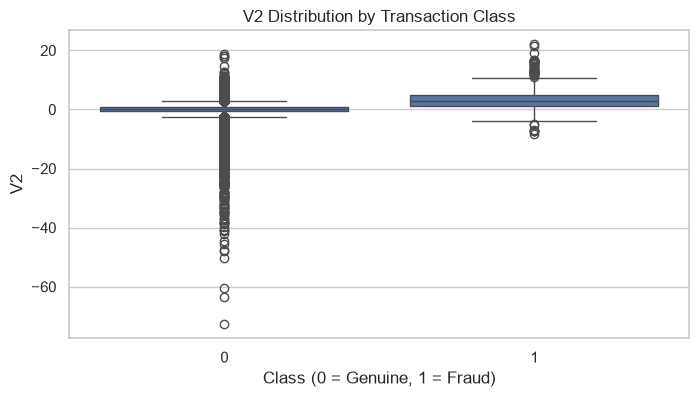

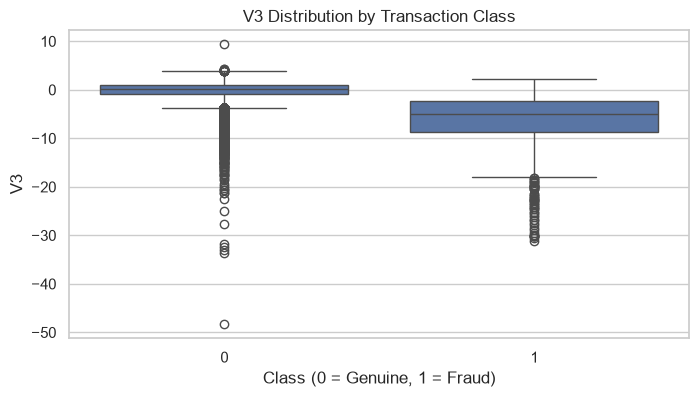

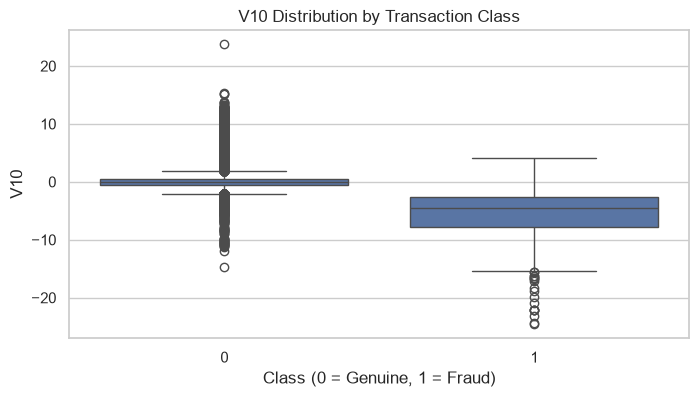

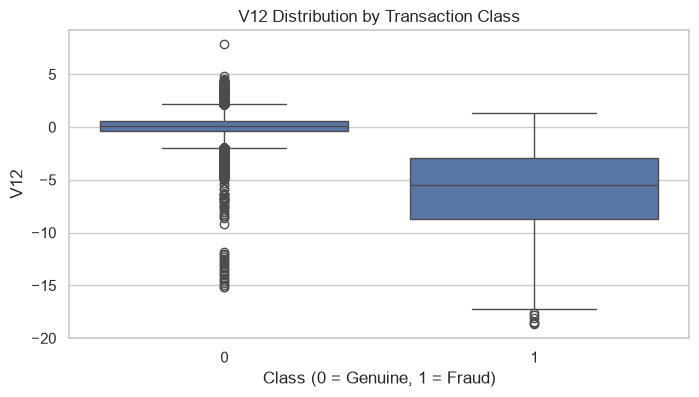

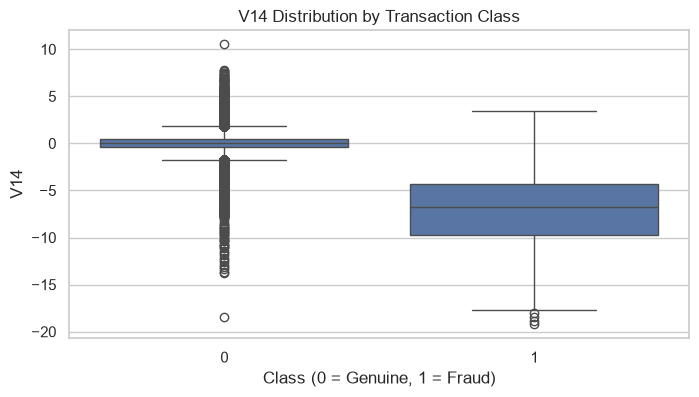

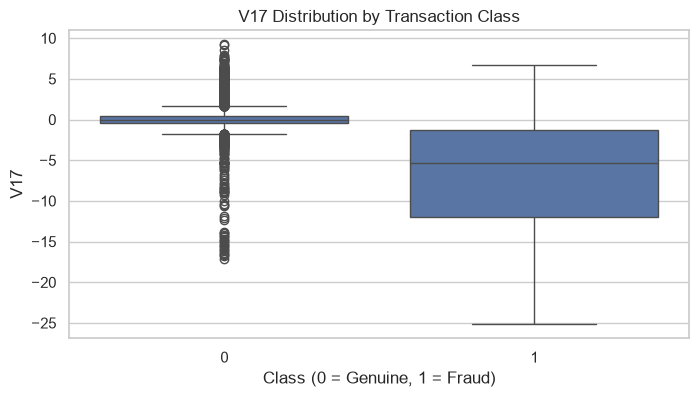

In [44]:
selected_features = ["V1", "V2", "V3", "V10", "V12", "V14", "V17"]

for feature in selected_features:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(data=df, x="Class", y=feature)
    
    plt.title(f"{feature} Distribution by Transaction Class")
    plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
    plt.ylabel(feature)
    
    plt.show()

In [45]:
class_feature_means = df.groupby("Class")[v_features].mean().T

class_feature_means

Class,0,1
V1,0.008258,-4.771948
V2,-0.006271,3.623778
V3,0.012171,-7.033281
V4,-0.007860,4.542029
V5,0.005453,-3.151225
V6,0.002419,-1.397737
V7,0.009637,-5.568731
V8,-0.000987,0.570636
V9,0.004467,-2.581123
V10,0.009824,-5.676883


In [46]:
correlation_matrix = df.corr(numeric_only=True)

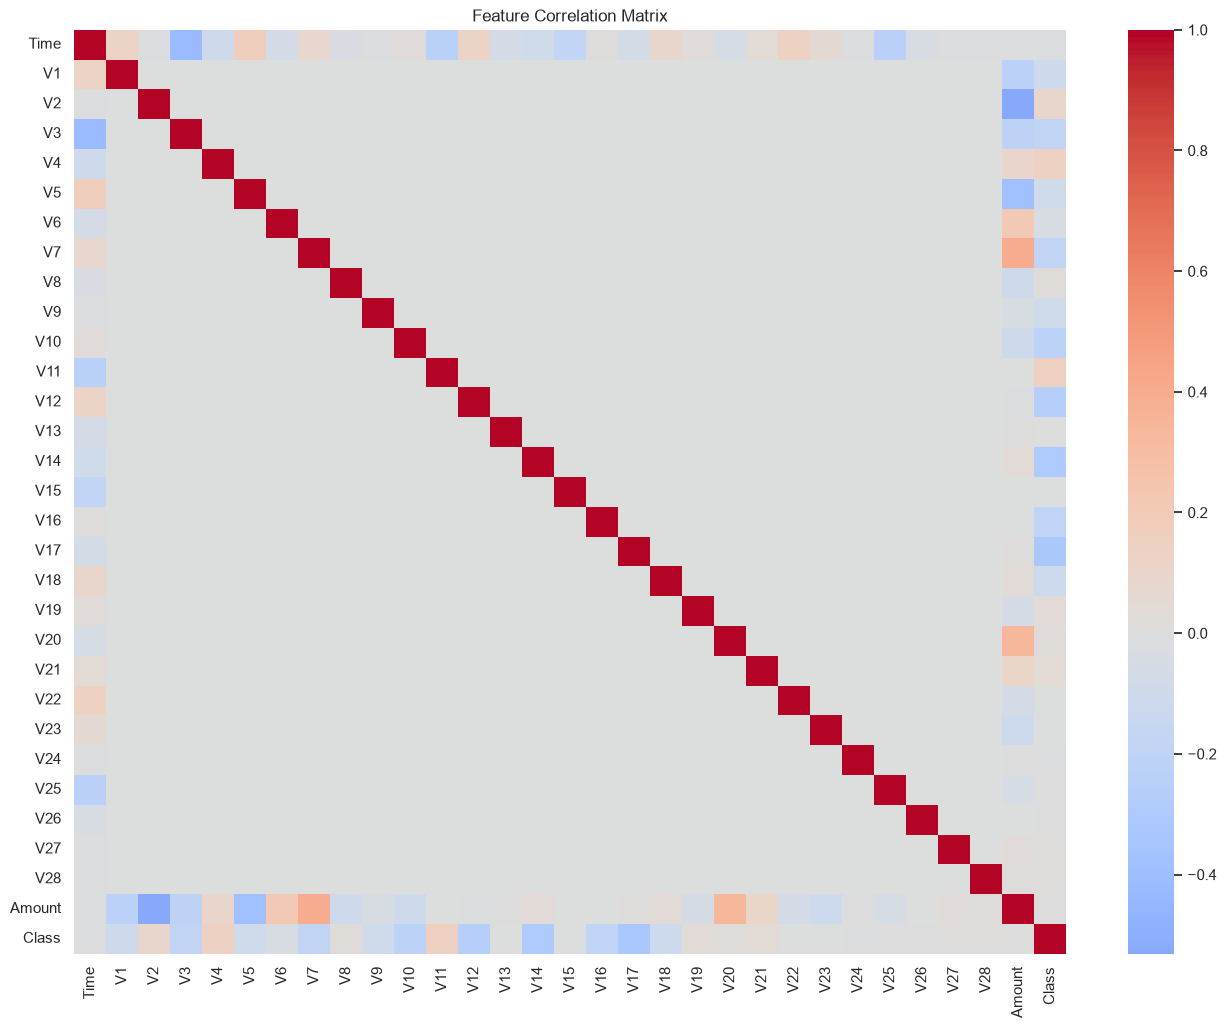

In [47]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

In [48]:
class_correlation = correlation_matrix["Class"].sort_values()

class_correlation

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Class     1.000000
Name: Class, dtype: float64

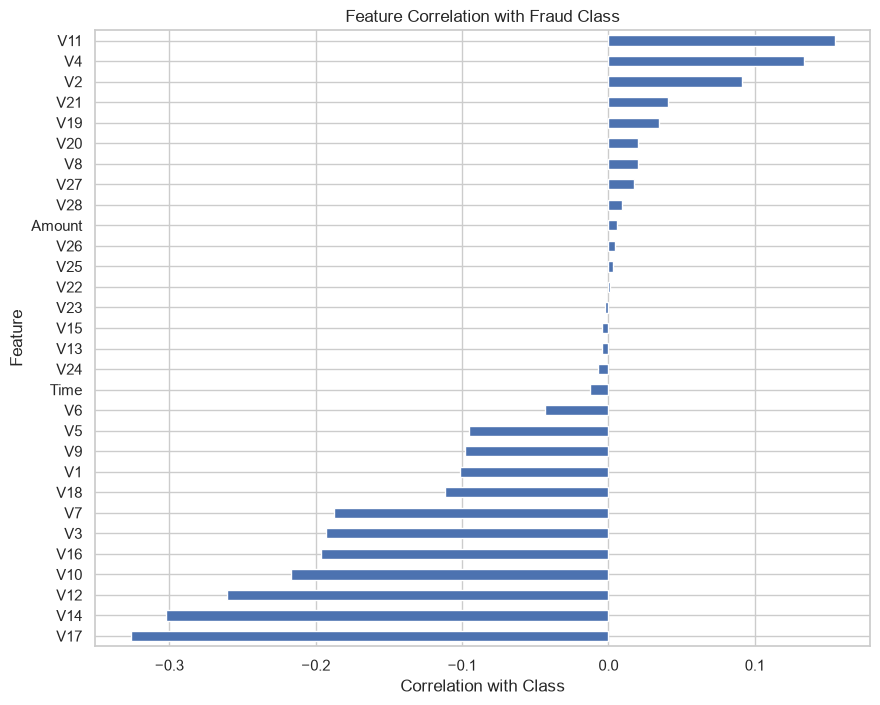

In [49]:
plt.figure(figsize=(10, 8))

class_correlation.drop("Class").plot(kind="barh")

plt.title("Feature Correlation with Fraud Class")
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")

plt.show()

In [50]:
top_correlations = (
    correlation_matrix["Class"]
    .drop("Class")
    .abs()
    .sort_values(ascending=False)
)

top_correlations.head(10)

V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64

In [51]:
top_features = top_correlations.head(10).index.tolist()

print("Top 10 features by absolute correlation:")
print(top_features)

Top 10 features by absolute correlation:
['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18']


In [52]:
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 5.6
Q3: 77.16499999999999
IQR: 71.565
Lower bound: -101.7475
Upper bound: 184.5125


In [53]:
amount_outliers = df[
    (df["Amount"] < lower_bound) |
    (df["Amount"] > upper_bound)
]

print("Potential Amount outliers:", len(amount_outliers))
print(f"Percentage: {len(amount_outliers) / len(df) * 100:.2f}%")

Potential Amount outliers: 31904
Percentage: 11.20%


In [54]:
amount_outliers["Class"].value_counts()

Class
0    31813
1       91
Name: count, dtype: int64

In [55]:
amount_outliers["Class"].value_counts(normalize=True) * 100

Class
0    99.714769
1     0.285231
Name: proportion, dtype: float64

In [56]:
amount_outliers["Amount"].describe()

count    31904.000000
mean       511.451107
std        585.479806
min        184.520000
25%        239.642500
50%        334.000000
75%        550.785000
max      25691.160000
Name: Amount, dtype: float64

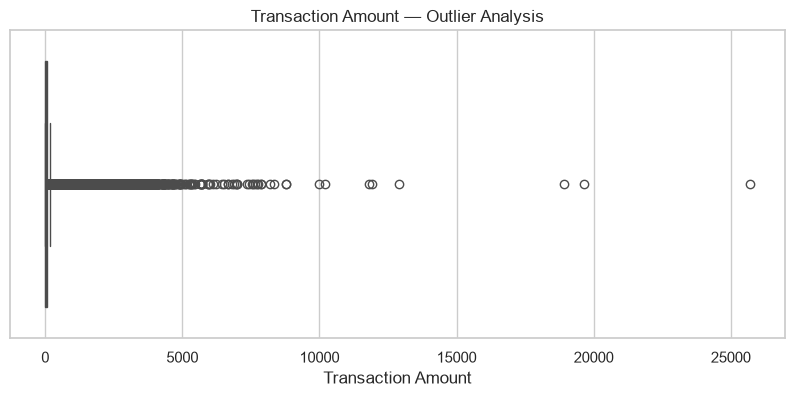

In [57]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df["Amount"])

plt.title("Transaction Amount — Outlier Analysis")
plt.xlabel("Transaction Amount")

plt.show()

In [58]:
fraud = df[df["Class"] == 1]
genuine = df[df["Class"] == 0]

print("Genuine transactions:", len(genuine))
print("Fraudulent transactions:", len(fraud))

Genuine transactions: 284315
Fraudulent transactions: 492


In [59]:
comparison = df.groupby("Class")["Amount"].agg(
    Count="count",
    Mean="mean",
    Median="median",
    Std="std",
    Minimum="min",
    Maximum="max"
)

comparison

,Count,Mean,Median,Std,Minimum,Maximum
Class,,,,,,
0,284315,88.291022,22.00,250.105092,0.0,25691.16
1,492,122.211321,9.25,256.683288,0.0,2125.87


In [60]:
class_feature_means = df.groupby("Class")[top_features].mean().T

class_feature_means

Class,0,1
V17,0.011535,-6.665836
V14,0.012064,-6.971723
V12,0.010832,-6.259393
V10,0.009824,-5.676883
V16,0.007164,-4.139946
V3,0.012171,-7.033281
V7,0.009637,-5.568731
V11,-0.006576,3.800173
V4,-0.007860,4.542029
V18,0.003887,-2.246308


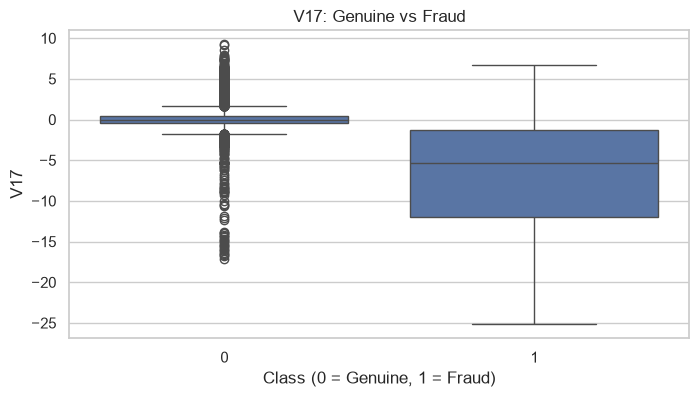

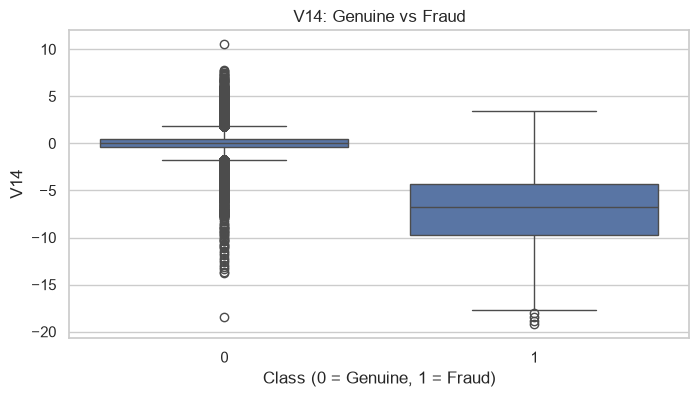

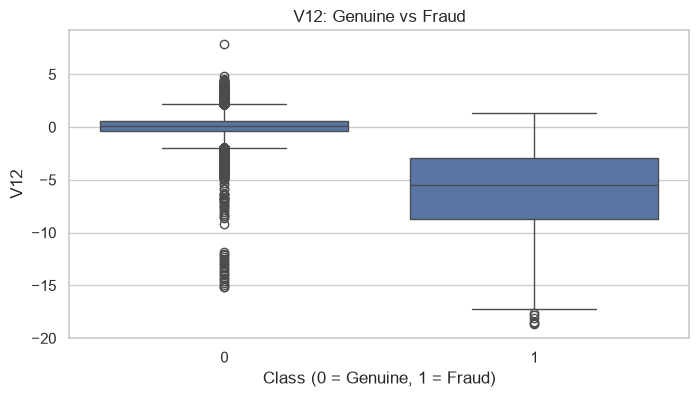

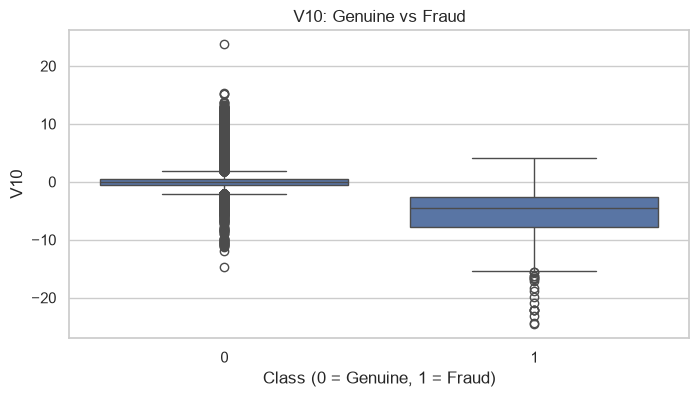

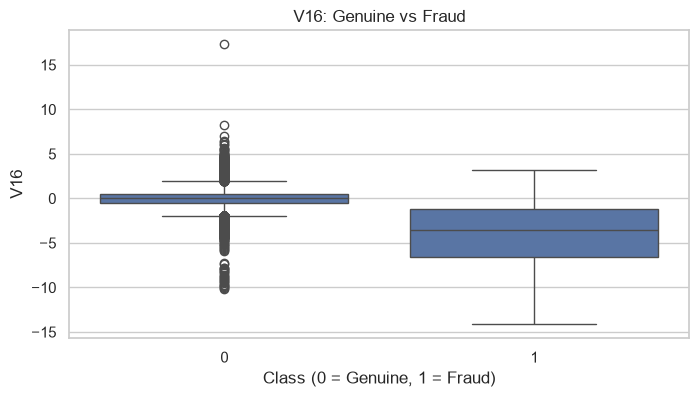

In [61]:
for feature in top_features[:5]:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(data=df, x="Class", y=feature)
    
    plt.title(f"{feature}: Genuine vs Fraud")
    plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
    plt.ylabel(feature)
    
    plt.show()

In [ ]:
# # Final EDA Findings

# ## 1. Dataset Structure
# - The dataset contains 284,807 transaction records and 31 columns.
# - The features consist of `Time`, anonymized PCA-transformed features `V1`–`V28`, `Amount`, and the target variable `Class`.

# ## 2. Data Quality
# - No missing values were detected.
# - No infinite values were detected.
# - 1,081 duplicate rows were identified, representing approximately 0.38% of the dataset.
# - No negative transaction amounts were found.

# ## 3. Class Distribution
# - 284,315 transactions (99.8273%) are genuine.
# - 492 transactions (0.1727%) are fraudulent.
# - This demonstrates a severe class imbalance and makes accuracy alone unsuitable as the primary evaluation metric.

# ## 4. Transaction Amount
# - The mean transaction amount is approximately 88.35, while the median is 22.00.
# - 1,825 transactions have an Amount of zero.
# - The maximum transaction amount is 25,691.16.
# - Fraudulent transactions have a median Amount of 9.25 compared with 22.00 for genuine transactions.
# - IQR analysis identified 31,904 potential Amount outliers (11.20%).
# - These observations were not removed because extreme values may contain useful fraud-related information.

# ## 5. Transaction Time
# - The Time feature ranges from 0 to 172,792 seconds.
# - 124,592 unique Time values are present.
# - Time distributions were compared between genuine and fraudulent transactions.

# ## 6. V1–V28 Features
# - V1–V28 are anonymized transformed features.
# - Their distributions and class-wise behaviour were analysed.
# - No business interpretation was assigned to these anonymized features.

# ## 7. Correlation Analysis
# The strongest absolute linear correlations with the target were observed for:
# 1. V17
# 2. V14
# 3. V12
# 4. V10
# 5. V16
# 6. V3
# 7. V7
# 8. V11
# 9. V4
# 10. V18

# Correlation was used for exploratory understanding and not as the sole basis for feature selection.

# ## 8. Preprocessing Implications
# Based on the EDA, the preprocessing stage should investigate:
# - Appropriate handling of duplicate records
# - Class imbalance
# - Feature scaling where required
# - Treatment/transformation of skewed `Amount`
# - Appropriate handling of extreme values without blindly deleting potential fraud signals
# - Train/test splitting using a strategy appropriate for the highly imbalanced target
# - Feature engineering only where justified